In [1]:
try:
    import xgboost as xgb
except:
    %pip install -q xgboost
    import xgboost as xgb

In [2]:
!pip show xgboost

Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, nvidia-nccl-cu12, scipy
Required-by: TPOT


In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device GPU: Tesla T4
ℹ️ No. of CPU: 4 cores


In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random
from scipy.optimize import minimize

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, LabelEncoder
from sklearn.model_selection import KFold, StratifiedKFold, RepeatedStratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, ConfusionMatrixDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [5]:
## -- Global Settings --
sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e6/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

    ORIG_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/'
    orig = pd.read_csv(ORIG_PATH+'star_classification.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e4 | Irrigation Need/_irrigation_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
    test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
    orig = pd.read_csv(PATH+'irrigation_prediction.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]
CATS   = ['spectral_type', 'galaxy_population']

NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping = {c: i for i, c in enumerate(train[TARGET].unique())}
r_mapping = {i: c for i, c in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in [('Train', train), ('Test', test), ('Original', orig)]:
    print(f"{name} shape: {df.shape}")

print(f"\nTotal nums: {len(NUMS)}")
print(f"Total cats: {len(CATS)}")
print(f"Total base: {len(BASE)}")

Train shape: (577347, 11)
Test shape: (247435, 10)
Original shape: (100000, 18)

Total nums: 8
Total cats: 2
Total base: 10


In [7]:
display(train.head())
train.info()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  object 
 9   galaxy_population  577347 non-null  object 
 10  class              577347 non-null  int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 48.5+ MB


In [8]:
train.describe() 

,alpha,delta,u,g,r,i,z,redshift,class
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135,0.489465
std,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070,0.732431
min,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970,0.000000
25%,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052,0.000000
50%,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525,0.000000
75%,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390,1.000000
max,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780,2.000000


In [9]:
## -- ['spectral_type', 'galaxy_population'] derivation for original data --
def spectral_type(g, r):
    return pd.cut(
        r-g, 
        [-np.inf, -1, -0.5, 0, np.inf],
        labels=['M', 'G/K', 'A/F', 'O/B']
    ).astype(str)

def galaxy_population(u, r):
    return pd.cut(
        u-r, 
        [-np.inf, 2.2, np.inf],
        labels=['Blue_Cloud', 'Red_Sequence']
    ).astype(str)

orig['spectral_type'] = spectral_type(orig.g, orig.r)
orig['galaxy_population'] = galaxy_population(orig.u, orig.r)

orig

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,spectral_type,galaxy_population
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171,M,Red_Sequence
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427,A/F,Blue_Cloud
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299,M,Red_Sequence
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775,M,Blue_Cloud
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842,M,Red_Sequence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,0,0.000000,9374,57749,438,M,Blue_Cloud
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,0,0.404895,7626,56934,866,M,Red_Sequence
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,0,0.143366,2764,54535,74,M,Red_Sequence
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,0,0.455040,6751,56368,470,M,Red_Sequence


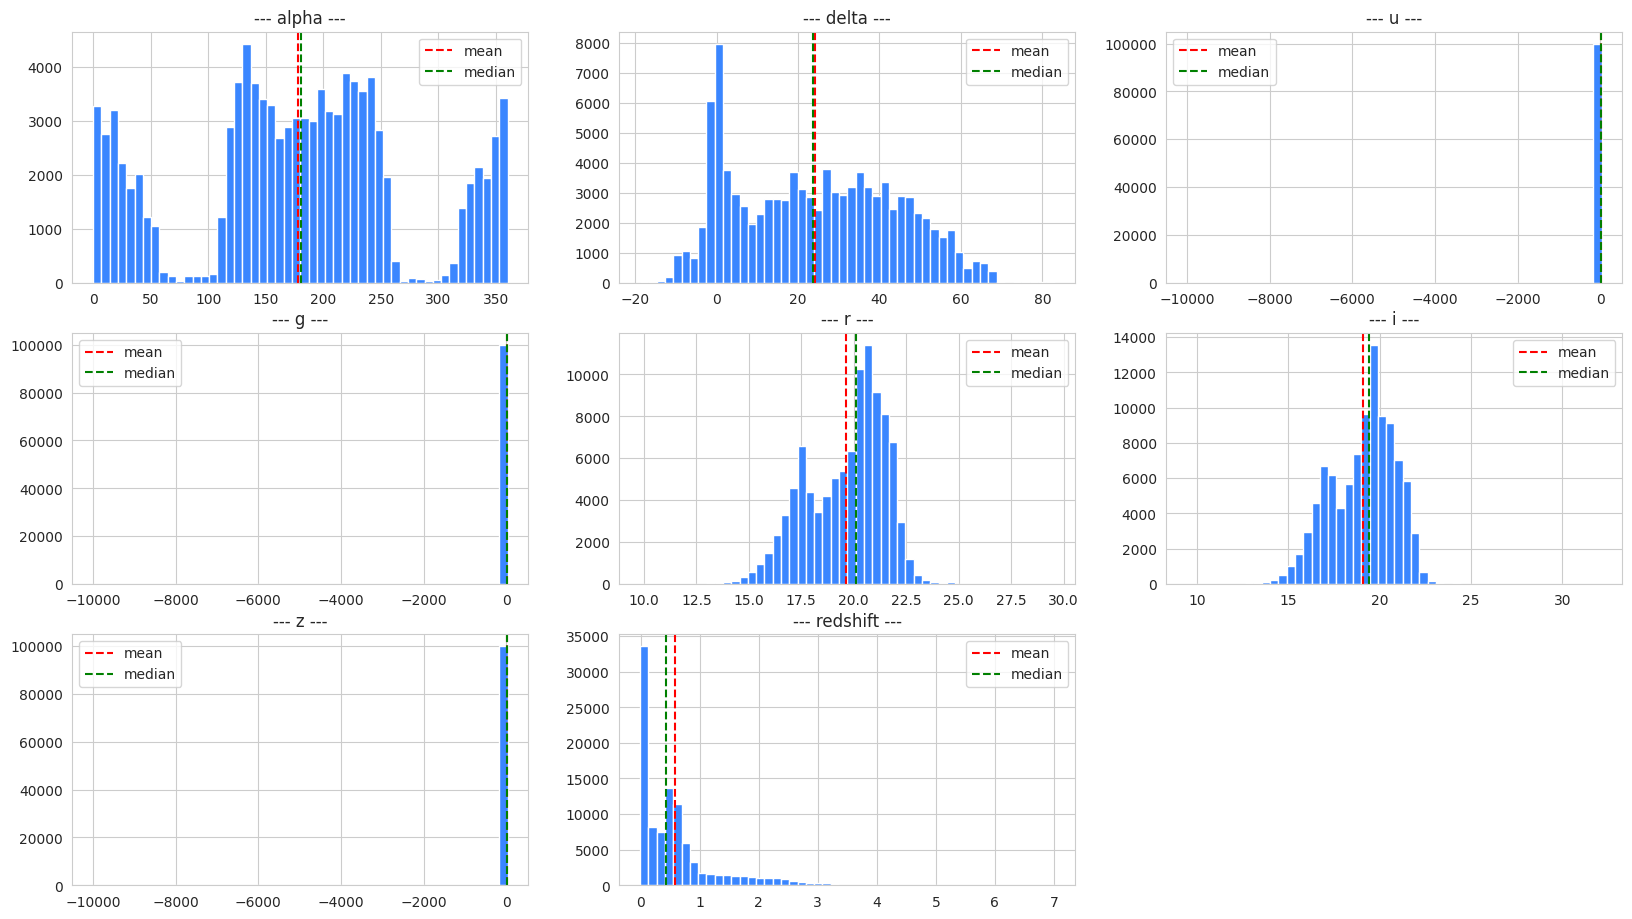

In [10]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'--- {col} ---')
    plt.legend()
    
plt.show()

In [11]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    # ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         # pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient(cmap='inferno')

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
Train,439819,444062,577347,577347,577347,577347,577347,573975,4,2
Test,200893,201819,247435,247435,247435,247435,247435,246031,4,2


## FEATURE ENGINEERING

In [12]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        sample_weights = np.array([opt[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    results = balanced_accuracy_score(y_true, pred_labels)
    return results

print('- Helper Functions Ready -')

- Helper Functions Ready -


In [13]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X, y, categories):
    for c in categories:
        X[c] = X[c].factorize()[0]
        X[c] = X[c].astype('category')
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
    
    ## -- Compute Model Importances --
    print('Training base model... ', end='')
    model.fit(X_train, y_train, sample_weight=get_weights(y_train, y))
    model_importances = pd.Series(model.feature_importances_, index=X.columns)
    print('Complete!')

    ## -- Compute Permutation Importances --
    print('Training permutation... ', end='')
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=10, # max_samples=0.8,
        sample_weight=get_weights(y_test, y),
        scoring='balanced_accuracy',
        random_state=42, n_jobs=-1
    )
    perm_sorted_idx = result.importances_mean.argsort()
    print('Complete!')

    fig, axs = plt.subplots(1, 2, figsize=(15, 8))
    model_importances.sort_values().plot.barh(ax=axs[0])
    axs[0].set_xlabel("Model importance")
    
    axs[1].boxplot(
        result.importances[perm_sorted_idx].T, orientation='horizontal',
        tick_labels=X.columns[perm_sorted_idx], whis=(0, 100),
    )
    axs[1].axvline(x=0, color="k", linestyle="--")
    axs[1].set_xlabel("Permutaion importance")

    fig.suptitle("Impurity-based vs. permutation importances on validation data")
    _ = fig.tight_layout()

print('Plot function script ready!')

Plot function script ready!


Training base model... Complete!
Training permutation... Complete!
CPU times: user 4.23 s, sys: 395 ms, total: 4.63 s
Wall time: 10.3 s


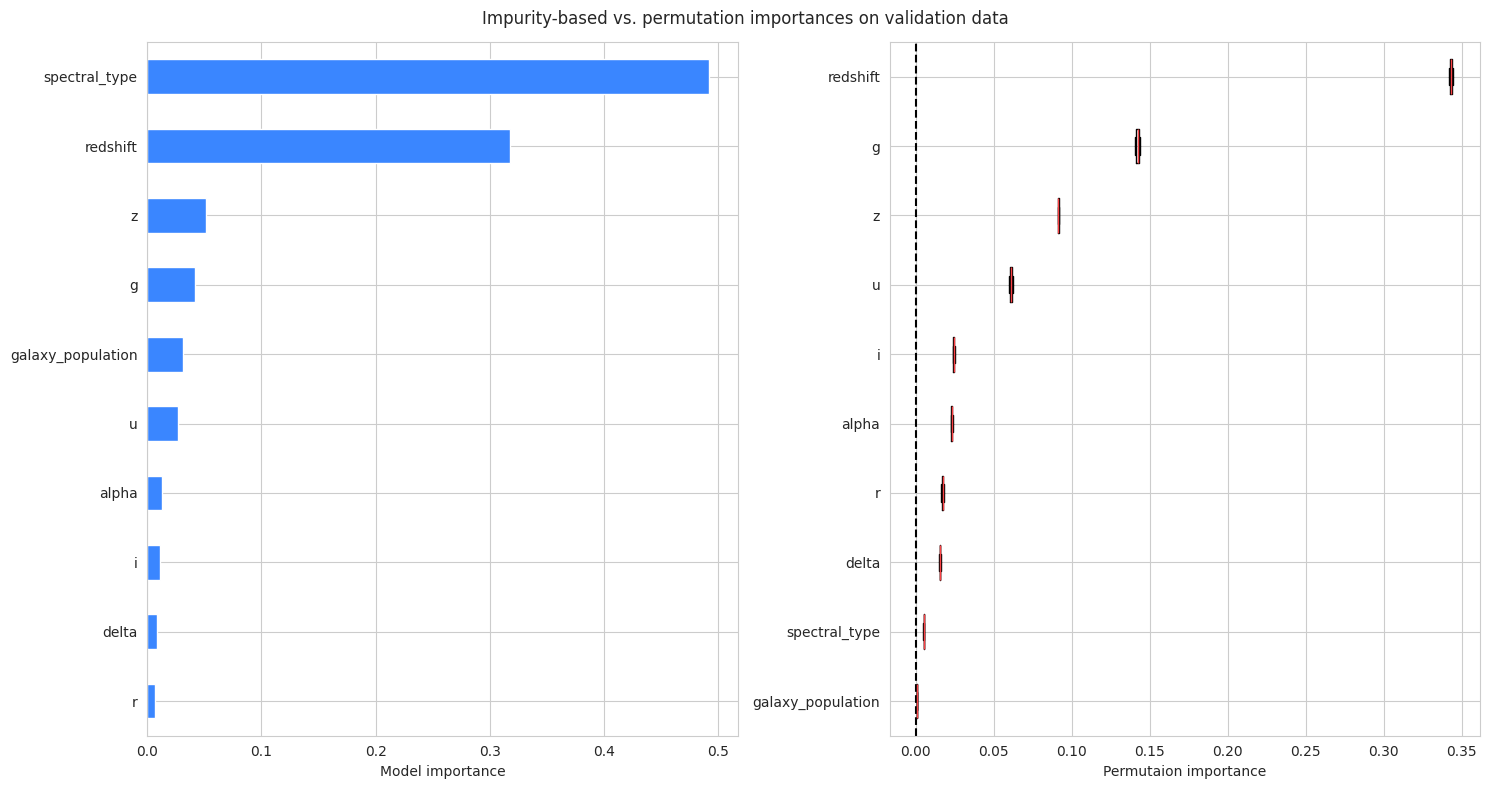

In [14]:
%%time 

PARAMS = {
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'num_class': 3,
    'enable_categorical': True,
    'random_state': CFG['SEED'],
    'verbosity': 0,
    'n_jobs': -1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

xgb_model = xgb.XGBClassifier(**PARAMS)

plot_permutation_importance(xgb_model, train[BASE], train[TARGET], CATS)

In [15]:
# ## -- Optimal Binning --
# try:
#     import optbinning
# except:
#     %pip install -q -U optbinning
#     import optbinning

# def _opt_multiclass_binning(
#     x_tr, y_tr, x_vl, x_ts, bin_features,
#     solver='cp', metric='mean_woe', pre_bins=100, period=100):
#     """
#     metric: 'mean_woe' or 'weighted_mean_woe': floats or 'indices': integers
#     """
#     x_train = x_tr.copy()
#     x_valid = x_vl.copy()
#     x_test  = x_ts.copy()

#     opt_modules_per_col = []
#     opt_cols = []

#     for col in tqdm(bin_features, desc='Optimal_Multiclass_Binning'):
#         # print(f'{col}... ', end='')
#         opt_multi_b = optbinning.MulticlassOptimalBinning(
#             name=col,
#             prebinning_method='cart', # d='cart', 'quantile'
#             min_prebin_size=0.02, # d=0.05
#             max_n_prebins=pre_bins, # d=20
#             # min_n_bins=2, max_n_bins=100,
#             # min_bin_size=0.1, max_bin_size=0.9,
#             solver=solver,
#             time_limit=period, # d=100 (secs)
#             # verbose=True,
#         )

#         opt_multi_b.fit(x_train[col].to_numpy(), y_tr.to_numpy())
#         # display(optb.information(print_level=0))

#         new_col = f'{col}_optBin'
#         x_train.loc[:, new_col] = opt_multi_b.transform(x_train[col].to_numpy(), metric=metric)
#         x_valid.loc[:, new_col] = opt_multi_b.transform(x_valid[col].to_numpy(), metric=metric)
#         x_test.loc[:, new_col]  = opt_multi_b.transform(x_test[col].to_numpy(),  metric=metric)

#         opt_cols.append(new_col)
#         opt_modules_per_col.append(opt_multi_b)

#     # print(f'Done!')

#     return opt_modules_per_col, opt_cols, x_train, x_valid, x_test

# print('Binning function ready')

In [16]:
# opt_bins, opt_bin_cols, train2, orig2, test2 = _opt_multiclass_binning(
#     x_tr=train,
#     y_tr=train[TARGET],
#     x_vl=orig,
#     x_ts=test,
#     bin_features=NUMS,
#     solver='mip', # 'cp', 'mip', 'lr'
#     metric='weighted_mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
#     pre_bins=100, 
#     period=100,
# )

# print(f"Total bin features: {len(opt_bin_cols)}")
# train2.head()

In [17]:
# BIN_TABLES = []

# for opt_ in opt_bins:
#     # print(opt_bins[col_n].status, opt_bins[col_n].splits)
#     opt_table = opt_.binning_table
#     opt_table.build()
#     # display(opt_table.build())
#     BIN_TABLES.append(opt_table)

# print('Binned features:', len(BIN_TABLES))
# print('Classes:', BIN_TABLES[0].classes)

# ## -- Plot optimal bin points --
# for i, opt_ in enumerate(BIN_TABLES):
#     opt_.plot(show_bin_labels=True, figsize=(18, 5))
#     print()

In [18]:
# for col in opt_bin_cols:
#     print(f"{col}: {train2[col].nunique()}")

In [19]:
# BIN_TABLES[0].analysis()

In [20]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [21]:
NUMS

['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

In [22]:
for col in ['alpha','delta','redshift']:
    print(f"\nRounding... ", end='')
    for r in range(-3, 6):
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    # print(f"\nDigitizing... ", end='')
    # for d in range(-3, 7):
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nEqual binning... ", end='')
    # for b in [32, 64, 128]: # 100, 500, 1000
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQuantile binning... ", end='')
    # for q in [32, 64, 128]:
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ ROUNDS: {len(ROUNDS)}')
print(f"✅ DIGITS: {len(DIGITS)}")
print(f"✅ E_BINS: {len(E_BINS)}")
print(f"✅ Q_BINS: {len(Q_BINS)}")


Rounding... alpha_round_-3, alpha_round_-2, alpha_round_-1, alpha_round_0, alpha_round_1, alpha_round_2, alpha_round_3, alpha_round_4, alpha_round_5, 
Rounding... delta_round_-3, delta_round_-2, delta_round_-1, delta_round_0, delta_round_1, delta_round_2, delta_round_3, delta_round_4, delta_round_5, 
Rounding... redshift_round_-3, redshift_round_-2, redshift_round_-1, redshift_round_0, redshift_round_1, redshift_round_2, redshift_round_3, redshift_round_4, redshift_round_5, 
✅ ROUNDS: 21
✅ DIGITS: 0
✅ E_BINS: 0
✅ Q_BINS: 0


In [23]:
for col in ['delta']: # 'u', 'g', 'r', 'i', 'z',
    # print(f"\nRounding... ", end='')
    # for r in range(-3, 5):
    #     r_n = f"{col}_round_{r}"
    #     print(r_n+', ', end='')
    #     train[r_n] = train[col].round(r).astype('int32')
    #     test[r_n]  = test[col].round(r).astype('int32')
    #     orig[r_n]  = orig[col].round(r).astype('int32')
    #     ## -- Drop irrelevant features --
    #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
    #         DROP_COLS.append(r_n)
    #     else:
    #         ROUNDS.append(r_n)
    
    # print(f"\nExtracting digits... ", end='')
    # for d in range(-3, 6):
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nEqual binning... ", end='')
    # for b in [100]: # 50, 100, 400
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)
        
    print(f"\nQuantile binning.. ", end='')
    for q in [90, 180, 360]: 
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ ROUNDS: {len(ROUNDS)}')
print(f"✅ DIGITS: {len(DIGITS)}")
print(f"✅ E_BINS: {len(E_BINS)}")
print(f"✅ Q_BINS: {len(Q_BINS)}")


Quantile binning.. delta_Qbin_90, delta_Qbin_180, delta_Qbin_360, 
✅ ROUNDS: 21
✅ DIGITS: 0
✅ E_BINS: 0
✅ Q_BINS: 3


In [24]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}\n")

train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Features dropped: ['alpha_round_-3', 'delta_round_-3', 'delta_round_-2', 'redshift_round_-3', 'redshift_round_-2', 'redshift_round_-1']



alpha_round_-2        5
alpha_round_-1       37
alpha_round_0       343
alpha_round_1       340
alpha_round_2       340
alpha_round_3       339
alpha_round_4       338
alpha_round_5       338
delta_round_-1       11
delta_round_0        95
delta_round_1        93
delta_round_2        92
delta_round_3        92
delta_round_4        92
delta_round_5        92
redshift_round_0      8
redshift_round_1      8
redshift_round_2      8
redshift_round_3      8
redshift_round_4      8
redshift_round_5      8
delta_Qbin_90        90
delta_Qbin_180      180
delta_Qbin_360      360
dtype: int64

In [25]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         # 1. Get value counts
#         v_counts = df[c].value_counts()
#         # 2. Identify values to replace (count <= threshold)
#         to_replace = v_counts[v_counts <= thresh].index
#         # 3. Apply condition: if value in low-freq list, assign 0, else keep it
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# for df in [train, test, orig]:
#     df = add_frequency_condition(df, DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [26]:
NUMS

['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

In [27]:
# ## -- Arithmetic interaction --
# arithmetic = []
# color_bands = []
# bands = ['u', 'g', 'r', 'i', 'z']

# for df in tqdm([train, test, orig]):
#     # for c1, c2 in tqdm(list(itertools.product(['u'], ['g', 'r'])), desc='One-to-Many'):
#     #     n_col = f"_{c1}_minus_{c2}"
#     #     df[n_col] = df[c1] - df[c2]
#     #     arithmetic.append(n_col)

#     for band in bands:
#         b_col = f"_{band}_/_redshift"
#         df[b_col] = (df[band] / (df['redshift'].abs() + 1e-6)).astype('float32')
#         color_bands.append(b_col)

# train[color_bands].head()

In [28]:
## -- Cyclic encoding --
for df in [train, test, orig]:
    for col in ['alpha', 'delta']:
        for p in [180, 360]:
            df[f"{col}_sin_{p}"] = np.sin(2 * np.pi * df[col] / p).astype('float32')
            df[f"{col}_cos_{p}"] = np.cos(2 * np.pi * df[col] / p).astype('float32')

In [29]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreate frequencies... ", end='')
# for col in ['spectral_type']:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print()
# print(f"✅ Total frequency features: {len(freq_cols)}")

# train[freq_cols].head()

In [30]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(['alpha','delta','redshift'], 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_COLS, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(TOP_COLS, LOW_COLS)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total interaction features: {len(INTER)}")

# train[INTER].head()

In [31]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [32]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== CategoryMeanEncoder =====

class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [33]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [34]:
# train, test, _, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(f"Appended original features: {len(orig_cols)}")

In [35]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in NUMS:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

In [36]:
## -- Factorize using combined data --
for c in CATS:
    combine  = pd.concat([train[c], test[c], orig[c]])
    combine  = combine.factorize()[0]
    # combine  = pd.Series(combine).astype('category')
    train[c] = combine[:len(train)]
    test[c]  = combine[len(train):len(train)+len(test)]
    orig[c]  = combine[len(train)+len(test):]

print('Label encoding complete!')

Label encoding complete!


In [37]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 42


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,alpha_round_-2,alpha_round_-1,alpha_round_0,alpha_round_1,alpha_round_2,alpha_round_3,alpha_round_4,alpha_round_5,delta_round_-1,delta_round_0,delta_round_1,delta_round_2,delta_round_3,delta_round_4,delta_round_5,redshift_round_0,redshift_round_1,redshift_round_2,redshift_round_3,redshift_round_4,redshift_round_5,delta_Qbin_90,delta_Qbin_180,delta_Qbin_360,alpha_sin_180,alpha_cos_180,alpha_sin_360,alpha_cos_360,delta_sin_180,delta_cos_180,delta_sin_360,delta_cos_360
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,0,100,150,148,147,147,147,147,147,20,17,17,16,16,16,16,0,0,0,0,0,0,38,77,155,-0.902822,0.430015,0.533847,-0.845581,0.558014,0.829832,0.291692,0.956512
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,0,100,130,128,128,127,127,127,127,30,32,32,32,32,32,32,0,0,0,0,0,0,59,119,238,-0.970200,-0.242305,0.788132,-0.615506,0.904034,0.427461,0.535041,0.844826
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,1,1,1,200,180,180,179,179,179,179,179,40,35,35,35,35,35,35,3,2,2,2,2,2,64,129,258,-0.007238,0.999974,0.003619,-0.999993,0.943741,0.330684,0.578496,0.815685


# ML TRAINING

In [38]:
# ## -- Test TE outputs --
# te = TargetEncoder(target_type='multiclass', random_state=CFG['SEED'])

# orig_te = te.fit_transform(orig[CATS], orig[TARGET])
# orig_te.columns = [f"TE_{c}" for c in orig_te.columns]

# pd.concat([orig[BASE+[TARGET]], orig_te], axis=1)

In [39]:
def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED'])

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

In [40]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cats):
    print(f"\n========== Starting Cross-Validation for {model_name} ==========")
    start = time()

    X = train_df[features]
    y = train_df[target]

    num_classes = y.nunique()

    class_weight_dict = {0: 0.6478731615859317, 1: 0.5804348658766916, 2: 398.17679096918584}
    
    oof_preds = np.zeros((len(train_df), num_classes))
    test_preds = np.zeros((len(test_df), num_classes))
    fold_scores = []
    
    calib_oof_preds = np.zeros((len(train_df), num_classes))
    calib_test_preds = np.zeros((len(test_df), num_classes))
    calib_fold_scores = []

    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n***** FOLD {idx + 1}/{kf.n_splits} *****")

        ## -- Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        # # y_train = np.concatenate([y_train, orig[target].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, orig_cols = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        # print(f"CategoryMeanEncoding: {len(cats)}")
        # cm_enc  = CategoryMeanTransformer(cat_cols=cats)
        # X_train = cm_enc.fit_transform(X_train, y_train).fillna(-1)
        # X_valid   = cm_enc.transform(X_valid).fillna(-1)
        # X_test  = cm_enc.transform(X_test).fillna(-1)

        # _, opt_cols, X_train, X_valid, X_test = _opt_multiclass_binning(
        #     x_tr=X_train,
        #     y_tr=y_train,
        #     x_vl=X_valid,
        #     x_ts=X_test,
        #     bin_features=NUMS,
        #     solver='cp', # 'cp', 'mip', 'lr'
        #     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
        #     pre_bins=100, 
        #     period=100,
        # )

        ## -- Target Encoding -- 
        te_cols = ROUNDS # + DIGITS #+ OPT_COLS #+ CATS_2
        print(f" • Target Encoding {len(te_cols)} features... ")
        X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=False)
        
        # te_cols = Q_BINS # + DIGITS #+ OPT_COLS #+ CATS_2
        # print(f" • Target Encoding {len(te_cols)} features... ")
        # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=False)

        combined = pd.concat([X_train, X_valid, X_test])
        for c in cats:
            combined[c] = combined[c].astype(str).astype('category')
        X_train = combined.iloc[:len(X_train)]
        X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        X_test  = combined.iloc[len(X_train)+len(X_valid):]

        ## -- Internal Split for Calibration --
        X_train_base, X_train_calib, y_train_base, y_train_calib = train_test_split(
            X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG['SEED'],
        )

        print(f' • Training base model {X_train_base.shape}... ')
        # display(X_train_base.head(3))

        xgb_model = xgb.XGBClassifier(
            **params, num_class=num_classes,
            callbacks=[xgb.callback.EarlyStopping(rounds=150)],
        )

        xgb_model.fit(
            X_train_base, y_train_base, 
            sample_weight=get_weights(y_train_base, y_train),
            eval_set=[(X_valid, y_valid)], verbose=300,
        )

        feat_importances.append(xgb_model.feature_importances_.ravel())

        oof_preds[val_idx] = xgb_model.predict_proba(X_valid)
        test_preds += xgb_model.predict_proba(X_test)

        fold_score = balanced_acc(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f'{CFG['YELLOW']}Score: {fold_score:.5f}{CFG['RESET']}')

        ## -- Calibrate for "true" probabilities --
        print(f' • Calibrating model {X_train_calib.shape}... ', end='')
    
        calib_model = CalibratedClassifierCV(
            FrozenEstimator(xgb_model), cv=None, method='isotonic', n_jobs=-1,
        )

        calib_model.fit(X_train_calib, y_train_calib,
            sample_weight=get_weights(y_train_calib, y_train))

        calib_oof_preds[val_idx] = calib_model.predict_proba(X_valid)
        calib_test_preds += calib_model.predict_proba(X_test)
        
        calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
        calib_fold_scores.append(calib_fold_score)
        print(f'{CFG['YELLOW']}Score: {calib_fold_score:.5f}{CFG['RESET']}')

    # Average test predictions
    test_preds /= kf.n_splits
    calib_test_preds /= kf.n_splits

    # Print final cross-validation results
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, (b, c) in enumerate(list(zip(fold_scores, calib_fold_scores)), 1):
        print(f" • Fold {i}: xgb -> {b:.5f} | calib -> {c:.5f}")

    overall_score = np.round(balanced_acc(y, oof_preds), 5)
    calib_overall_score = np.round(balanced_acc(y, calib_oof_preds), 5)
    
    print(f"{'='*40}")
    print(f"OOF:  XGB -> {overall_score} | CALIB -> {calib_overall_score}")
    print(f"{'-'*40}")
    print(f"AVG  Base: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print(f"AVG Calib: {np.mean(calib_fold_scores):.5f} ± {np.std(calib_fold_scores):.5f}")
    print(f"{'-'*40}")
    print(f"{CFG['GREEN']}Calib - Base:  {calib_overall_score - overall_score:.5f}{CFG['RESET']}")
    print(f"{'='*40}")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'scores': [overall_score, calib_overall_score],
        'models': xgb_model,
        'oof_preds': [oof_preds, calib_oof_preds],
        'test_preds': [test_preds, calib_test_preds],
        'importances': feat_importances,
        'val_data': [X_valid, y_valid],
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [41]:
version_name = 'xgb_v0_'

all_model_predictions = {}

ALL_CATS = CATS 

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

CFG['FOLDS'] = 8
kf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

kf

StratifiedKFold(n_splits=8, random_state=42, shuffle=True)

In [42]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_model_predictions:
#     all_model_predictions.clear()

# trial_ = '_'

# OUT_LOOP = [1, 3]
# INN_LOOP = [1, 3]
# p_name   = ['l1', 'l2']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f">>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             # 'sampling_method': 'gradient_based',
#             # # ----------------------------------
#             # 'grow_policy': 'lossguide',
#             # 'max_leaves': 32,
#             # 'max_depth': outer,
#             # # ----------------------------------
#             'objective': 'multi:softprob',
#             'eval_metric': 'mlogloss',
#             'n_estimators': 10_000,
#             'learning_rate': 0.1,
#             'subsample': 0.85,
#             'colsample_bytree': 0.6,
#             'reg_alpha': outer, # 1.0
#             'reg_lambda': inner, # 4.0
#             # 'gamma': outer,
#             # 'max_bin': 1024,
#             'min_child_weight': 5,
#             'enable_categorical': True,
#             'random_state': CFG['SEED'],
#             'verbosity': 0,
#             'n_jobs': -1,
#             'device': 'cuda' if torch.cuda.is_available() else 'cpu',
#         }

#         n = trial_ + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cats=ALL_CATS,
#         )

# print(f"\n=== Results ready for {len(all_model_predictions)} model(s) ===\n")

In [43]:
# TE_ROUNDS(alpha_delta_redshift) | cyclic(180, 360) | q_bin(delta_90, 180, 360)
# ========================================
#  • Fold 1: xgb -> 0.96470 | calib -> 0.96744
#  • Fold 2: xgb -> 0.96564 | calib -> 0.96767
#  • Fold 3: xgb -> 0.96478 | calib -> 0.96592
#  • Fold 4: xgb -> 0.96399 | calib -> 0.96566
#  • Fold 5: xgb -> 0.96523 | calib -> 0.96787
#  • Fold 6: xgb -> 0.96496 | calib -> 0.96659
#  • Fold 7: xgb -> 0.96458 | calib -> 0.96538
#  • Fold 8: xgb -> 0.96340 | calib -> 0.96540
# ========================================
# OOF:  XGB -> 0.96466 | CALIB -> 0.96649
# ----------------------------------------
# AVG  Base: 0.96466 ± 0.00066
# AVG Calib: 0.96649 ± 0.00098
# ----------------------------------------
# Calib - Base:  0.00183
# ========================================
# 11.10 mins

In [44]:
# all_model_scores = {}

# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'scores':
#             all_model_scores[k] = y

# raw_scores, calib_scores, names = [], [], []

# for k, group in all_model_scores.items():
#     raw_scores.append(group[0])
#     calib_scores.append(group[1])
#     names.append(k)

# plt.figure(figsize=(16, 6))
# ax1 = sns.lineplot(raw_scores, marker='s', label='xgb_model')
# ax2 = sns.lineplot(calib_scores, marker='o', label='calib_model')

# y_add = 1e-4

# for i, s1 in enumerate(raw_scores):
#     ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='b')

# for i, s2 in enumerate(calib_scores):
#     ax2.text(float(i), s2+y_add, s2, ha='center', va='baseline', color='r')

# plt.ylim((0.96, 0.97))
# plt.legend(loc='best')
# plt.xticks(range(len(names)), names, rotation=30)
# plt.title('XGB vs Calibrated', fontdict={'weight': 'semibold', 'size': 15})

# plt.tight_layout() 
# plt.show()

In [45]:
# all_model_scores

In [46]:
# all_feat_importances = {}
# all_val_data = {}

# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'importances':
#             all_feat_importances[k] = np.mean(y, axis=0)
#         elif x == 'val_data':
#             all_val_data[k] = y # -> [0] select X_val, [1] select y_valid

# top_n = 25

# for i, (m, fi) in enumerate(all_feat_importances.items()):
#     fi_df = pd.DataFrame({
#         'feature': all_val_data[m][0].columns, # -> [0] select X_val, [1] select y_valid
#         'importance': fi,
#     }).sort_values(by='importance', ascending=False).reset_index(drop=True)

#     plt.figure(figsize=(15, 7*len(all_feat_importances)))
#     # plt.subplot(len(all_feat_importances), 1, i+1)
#     sns.barplot(data=fi_df.head(top_n), x='importance', y='feature')
#     plt.title(f'{m} Avg. {CFG['FOLDS']}-Fold Feature Importances', fontweight='semibold')

#     plt.tight_layout() 
#     plt.show()

#     print()

In [47]:
# all_val_data[[*all_val_data.keys()][0]][0]

In [48]:
LR = 0.02
L1 = 0.0
L2 = 0.0
DEPTH = 6
GAMMA = 0.05
MIN_WEIGHT = 5
CALIBRATE  = 'iso'

In [49]:
## ======= BOOSTING =========
M_NAME = f"{version_name}gbt_"

PARAMS = {
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'n_estimators': 10_000,
    'max_depth': DEPTH,
    'learning_rate': LR,
    'subsample': 0.85,
    'colsample_bytree': 0.4,
    'reg_alpha': L1,
    'reg_lambda': L2,
    # 'gamma': GAMMA,
    'min_child_weight': MIN_WEIGHT,
    'enable_categorical': True,
    'random_state': CFG['SEED'],
    'verbosity': 0,
    'n_jobs': -1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

n = M_NAME + CALIBRATE
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

# for value in [3, 4]:
#     PARAMS['max_depth'] = value
#     n = M_NAME + str(value)
#     all_model_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=PARAMS,
#         train_df=train,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kf=kf,
#         cats=ALL_CATS,
#     )


========== Starting Cross-Validation for xgb_v0_gbt_iso ==========

***** FOLD 1/8 *****
 • Target Encoding 21 features... 
 • Training base model (353624, 105)... 
[0]	validation_0-mlogloss:1.07748
[300]	validation_0-mlogloss:0.15291
[600]	validation_0-mlogloss:0.12657
[900]	validation_0-mlogloss:0.11734
[1200]	validation_0-mlogloss:0.11222
[1500]	validation_0-mlogloss:0.10846
[1800]	validation_0-mlogloss:0.10575
[2100]	validation_0-mlogloss:0.10356
[2400]	validation_0-mlogloss:0.10178
[2700]	validation_0-mlogloss:0.10030
[3000]	validation_0-mlogloss:0.09915
[3300]	validation_0-mlogloss:0.09808
[3600]	validation_0-mlogloss:0.09723
[3900]	validation_0-mlogloss:0.09642
[4200]	validation_0-mlogloss:0.09580
[4500]	validation_0-mlogloss:0.09526
[4800]	validation_0-mlogloss:0.09480
[5100]	validation_0-mlogloss:0.09442
[5400]	validation_0-mlogloss:0.09407
[5700]	validation_0-mlogloss:0.09381
[6000]	validation_0-mlogloss:0.09357
[6300]	validation_0-mlogloss:0.09337
[6600]	validation_0-mloglo

In [50]:
# ==================================================
# Cross-Validation Results for xgb_v0_gbt_isotonic
# ==================================================
#  • FOLD 1: xgb -> 0.97657 | calib -> 0.97950
#  • FOLD 2: xgb -> 0.97652 | calib -> 0.97999
#  • FOLD 3: xgb -> 0.97889 | calib -> 0.98125
#  • FOLD 4: xgb -> 0.97652 | calib -> 0.98006
#  • FOLD 5: xgb -> 0.97623 | calib -> 0.98033
# ========================================
# OOF:  XGB -> 0.97694 | CALIB -> 0.98022
# ----------------------------------------
# AVG  Base: 0.97694 ± 0.00098
# AVG Calib: 0.98022 ± 0.00058
# ----------------------------------------
# Improved:  0.00328
# ========================================
# 160.62 mins

In [51]:
## ======= LOSS GUIDE =========
M_NAME = f"{version_name}loss_"
LEAVES = 128

PARAMS = {
    # ----------------------------------
    'grow_policy': 'lossguide',
    'max_leaves': LEAVES,
    'max_depth': 0,
    # ----------------------------------
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'n_estimators': 10_000,
    'learning_rate': LR,
    'subsample': 0.9,
    'colsample_bytree': 0.4,
    'reg_alpha': L1,
    'reg_lambda': L2,
    # 'gamma': GAMMA,
    'min_child_weight': MIN_WEIGHT,
    'enable_categorical': True,
    'random_state': CFG['SEED'],
    'verbosity': 0,
    'n_jobs': -1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

n = M_NAME + CALIBRATE
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

# for value in [3, 4]:
#     PARAMS['max_depth'] = value
#     n = M_NAME + str(value)
#     all_model_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=PARAMS,
#         train_df=train,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kf=kf,
#         cats=ALL_CATS,
#     )


========== Starting Cross-Validation for xgb_v0_loss_iso ==========

***** FOLD 1/8 *****
 • Target Encoding 21 features... 
 • Training base model (353624, 105)... 
[0]	validation_0-mlogloss:1.07625
[300]	validation_0-mlogloss:0.12725
[600]	validation_0-mlogloss:0.10597
[900]	validation_0-mlogloss:0.09956
[1200]	validation_0-mlogloss:0.09599
[1500]	validation_0-mlogloss:0.09387
[1800]	validation_0-mlogloss:0.09258
[2100]	validation_0-mlogloss:0.09198
[2400]	validation_0-mlogloss:0.09180
[2688]	validation_0-mlogloss:0.09193
Score: 0.96364
 • Calibrating model (151554, 105)... Score: 0.96690

***** FOLD 2/8 *****
 • Target Encoding 21 features... 
 • Training base model (353624, 105)... 
[0]	validation_0-mlogloss:1.07620
[300]	validation_0-mlogloss:0.12511
[600]	validation_0-mlogloss:0.10409
[900]	validation_0-mlogloss:0.09770
[1200]	validation_0-mlogloss:0.09416
[1500]	validation_0-mlogloss:0.09207
[1800]	validation_0-mlogloss:0.09078
[2100]	validation_0-mlogloss:0.09012
[2400]	valida

In [52]:
# ## ======= GRADIENT-BASED =========
# M_NAME = f"{version_name}grad_"

# PARAMS = {
#     'sampling_method': 'gradient_based',
#     # ------------------------------------
#     'objective': 'multi:softprob',
#     'eval_metric': 'mlogloss',
#     'n_estimators': 10_000,
#     'learning_rate': LR,
#     'max_depth': DEPTH,
#     'subsample': 0.9,
#     'colsample_bytree': 0.2,
#     'reg_alpha': L1,
#     'reg_lambda': L2,
#     'gamma': GAMMA,
#     'min_child_weight': MIN_WEIGHT,
#     'enable_categorical': True,
#     'random_state': SEED,
#     'verbosity': 0,
#     'n_jobs': -1,
#     'device': 'cuda' if torch.cuda.is_available() else 'cpu',
# }

# n = M_NAME + str(LR).split('.')[1]
# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=ALL_CATS,
# )

# # for value in [3, 4]:
# #     PARAMS['max_depth'] = value
# #     n = M_NAME + str(value)
# #     all_model_predictions[n] = Trainer_CV(
# #         model_name=n,
# #         params=PARAMS,
# #         train_df=train,
# #         test_df=test,
# #         features=FEATURES,
# #         target=TARGET,
# #         kf=kf,
# #         cats=ALL_CATS,
# #     )

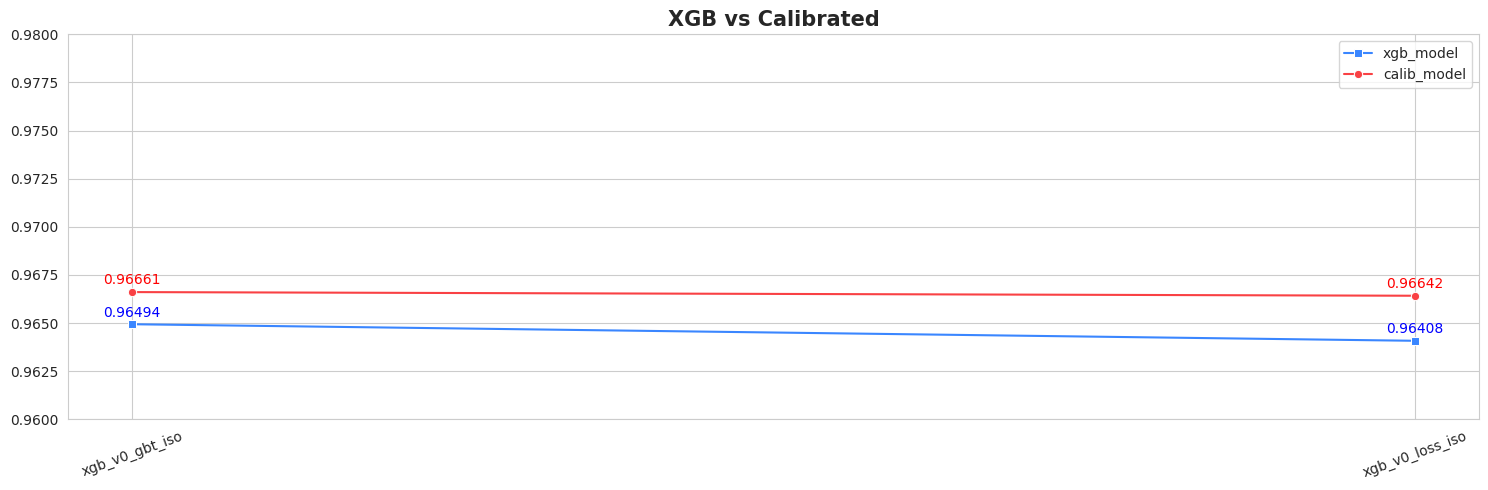

In [53]:
all_model_scores = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'scores':
            all_model_scores[k] = y

raw_scores, calib_scores, names = [], [], []

for k, group in all_model_scores.items():
    raw_scores.append(group[0])
    calib_scores.append(group[1])
    names.append(k)

plt.figure(figsize=(15, 5))
ax1 = sns.lineplot(raw_scores, marker='s', label='xgb_model')
ax2 = sns.lineplot(calib_scores, marker='o', label='calib_model')

y_add = 4e-4

for i, s1 in enumerate(raw_scores):
    ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='b')

for i, s2 in enumerate(calib_scores):
    ax2.text(float(i), s2+y_add, s2, ha='center', va='baseline', color='r')

plt.ylim((0.96, 0.98))
plt.legend(loc='best')
plt.xticks(range(len(names)), names, rotation=20)
plt.title('XGB vs Calibrated', fontdict={'weight': 'semibold', 'size': 15})

plt.tight_layout() 
plt.show()

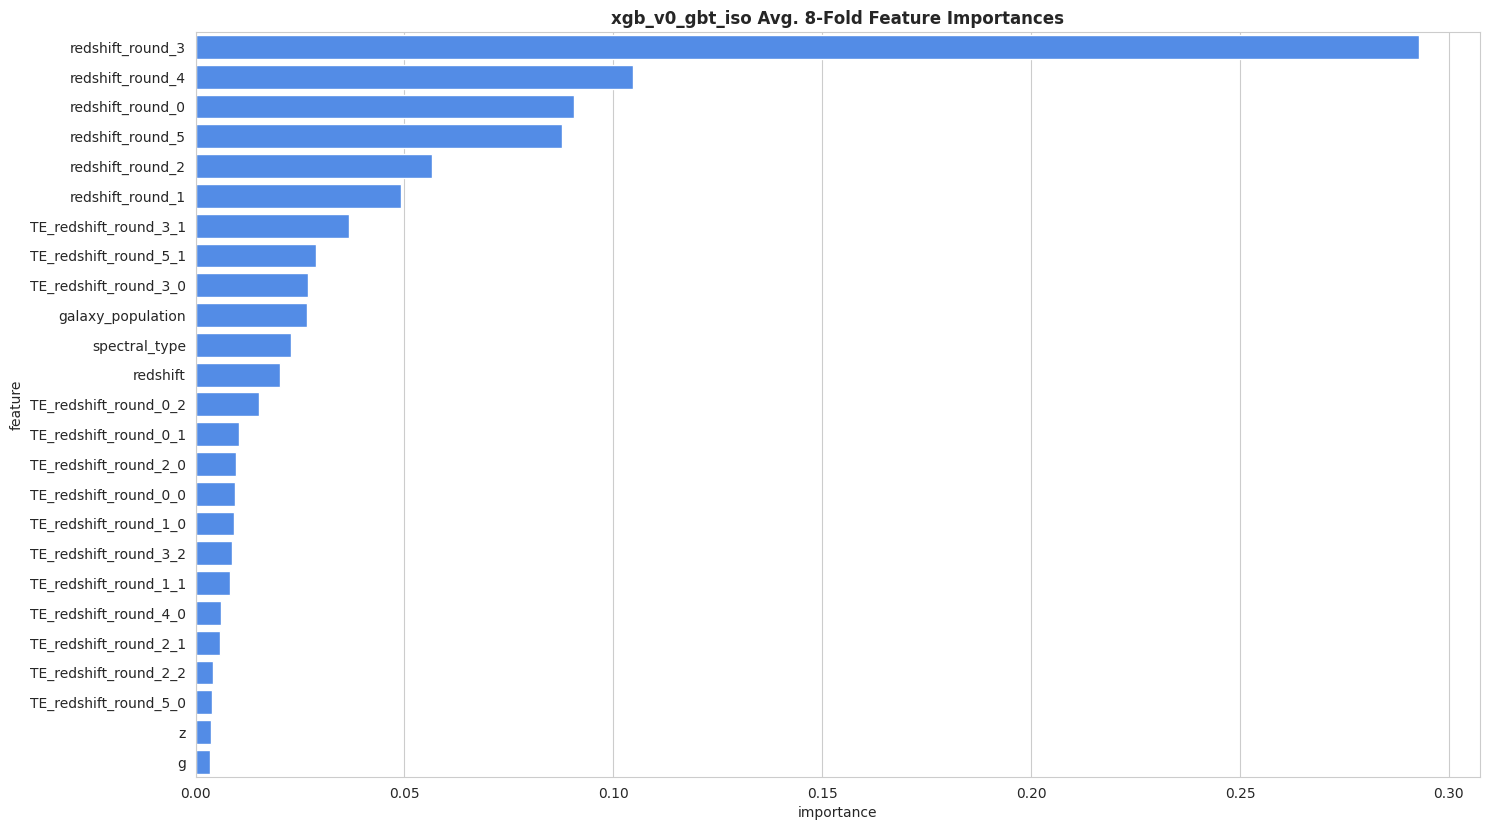

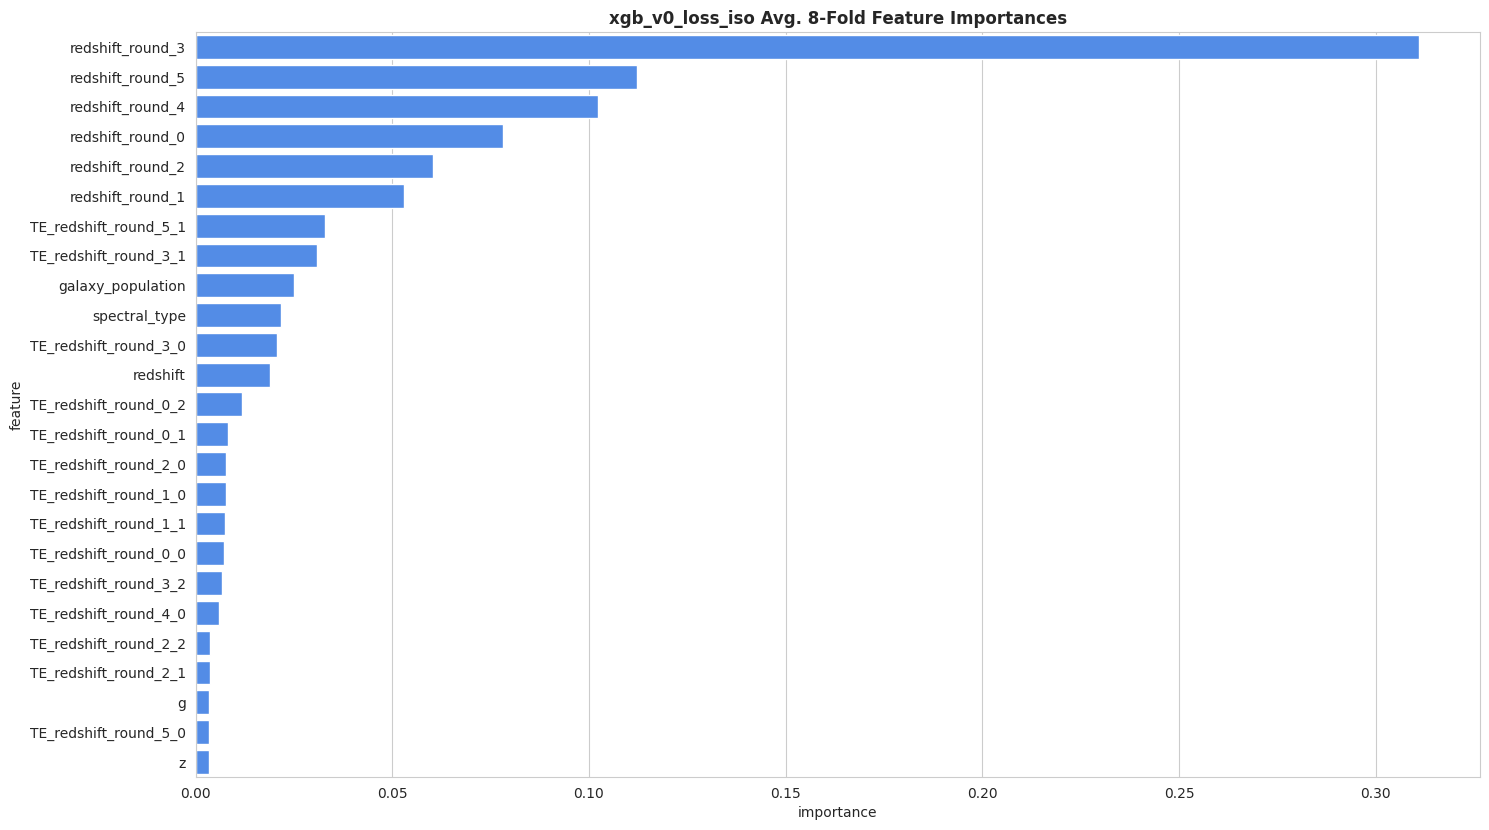

In [54]:
all_feat_importances = {}
all_val_data = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'importances':
            all_feat_importances[k] = np.mean(y, axis=0)
        elif x == 'val_data':
            all_val_data[k] = y # -> [0] select X_val, [1] select y_valid

top_n = 25

for i, (m, fi) in enumerate(all_feat_importances.items()):
    fi_df = pd.DataFrame({
        'feature': all_val_data[m][0].columns,
        'importance': fi,
    }).sort_values(by='importance', ascending=False).reset_index(drop=True)
    
    plt.figure(figsize=(15, 8*len(all_feat_importances)))
    plt.subplot(len(all_feat_importances), 1, i+1)
    sns.barplot(data=fi_df.head(top_n), x='importance', y='feature')
    plt.title(f'{m} Avg. {CFG['FOLDS']}-Fold Feature Importances', fontweight='semibold')

    plt.tight_layout() 
    plt.show()

    print()

In [55]:
# !rm -r /kaggle/working

In [56]:
## -- Get OOF PREDICTIONS --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            ## -- Create base submission file --
            base_n = f"{k}_{str(raw_scores[i]).split('.')[1]}"
            np.save(f"oof_base_{base_n}_.npy", y[0])
            print(f'OOF file for base model saved!')

            ## -- Create calib submission file --
            cal_n = f"{k}_{str(calib_scores[i]).split('.')[1]}"
            np.save(f"oof_calib_{cal_n}_.npy", y[1])
            print(f'OOF file for calibrated model saved!')
            
            print()

OOF file for base model saved!
OOF file for calibrated model saved!

OOF file for base model saved!
OOF file for calibrated model saved!



In [57]:
## -- Get TEST PREDICTIONS / SUBMISSIONS --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            base_n_1 = f"{k}_{str(raw_scores[i]).split('.')[1]}"
            np.save(f"test_base_{base_n_1}_.npy", y[0])
            base_preds = np.argmax(y[0], axis=1)
            submit[TARGET] = pd.Series(base_preds).map(r_mapping)
            submit.to_csv(f'submit_base_{base_n_1}_.csv', index=False)
            print(f'Submission base TEST file saved! {base_preds.shape}')

            ## -- Calib submission file --
            cal_n_1 = f"{k}_{str(calib_scores[i]).split('.')[1]}"
            np.save(f"test_calib_{cal_n_1}_.npy", y[1])
            calib_preds = np.argmax(y[1], axis=1)
            submit[TARGET] = pd.Series(calib_preds).map(r_mapping)
            submit.to_csv(f'submit_calib_{cal_n_1}_.csv', index=False)
            print(f'Submission calib TEST file saved! {calib_preds.shape}')

            print()

Submission base TEST file saved! (247435,)
Submission calib TEST file saved! (247435,)

Submission base TEST file saved! (247435,)
Submission calib TEST file saved! (247435,)



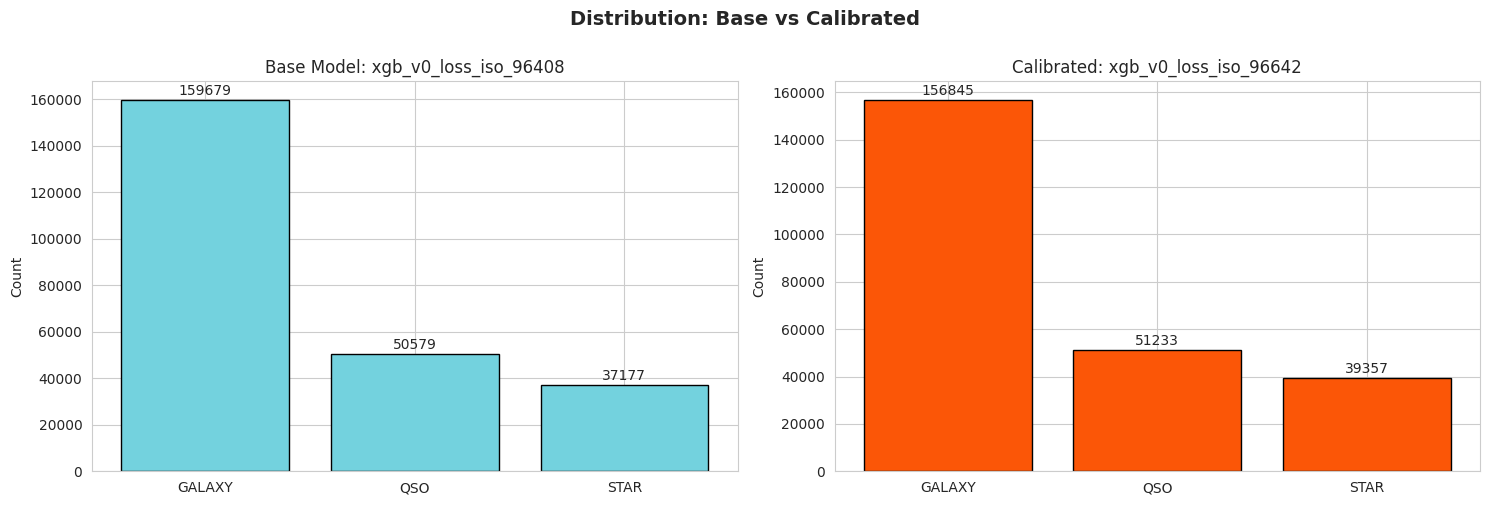

In [58]:
class_names = [k for k in mapping.keys()]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, preds, title, color in [
    (axes[0], base_preds, f'Base Model: {base_n_1}', '#73D2DE'),
    (axes[1], calib_preds, f'Calibrated: {cal_n_1}', '#FB5607'),
]:
    counts = [np.sum(preds == i) for i in range(len(np.unique(base_preds)))]
    ax.bar(class_names, counts, color=color, edgecolor='k')
    ax.set_title(title)
    ax.set_ylabel('Count')

    for i, c in enumerate(counts):
        ax.text(i, c+2000, str(c), ha='center', fontsize=10)

plt.suptitle('Distribution: Base vs Calibrated', fontsize=14, y=1.00, fontweight='semibold')

plt.tight_layout()
plt.show()